In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
from pathlib import Path
import pandas as pd

path_x = Path("../data/raw/X.csv")
df_x = pd.read_csv(path_x, sep=",", decimal=".", encoding="utf-8-sig")
path_y = Path("../data/raw/Y.csv")
df_y = pd.read_csv(path_y, sep=";", decimal=",", encoding="utf-8-sig")
path_z = Path("../data/raw/Z.csv")
df_z = pd.read_csv(path_z, sep=",", decimal=".", encoding="utf-8-sig")

df_x["Price"] = df_x["Price"].astype(float)
df_y["Price"] = df_y["Price"].astype(float)
df_z["Price"] = df_z["Price"].astype(float)
df_x["Date"] = pd.to_datetime(df_x["Date"], format='%Y-%m-%d')
df_y["Date"] = pd.to_datetime(df_y["Date"], dayfirst=True)
df_z["Date"] = pd.to_datetime(df_z["Date"], format='%Y-%m-%d')

df_x = df_x.rename(columns={"Price": "Price_X"})
df_y = df_y.rename(columns={"Price": "Price_Y"})
df_z = df_z.rename(columns={"Price": "Price_Z"})

df = df_x.merge(df_y, on="Date", how="outer").merge(df_z, on="Date", how="outer")
df.dropna(inplace=True)
df = df.sort_values("Date").reset_index(drop=True)

path_h = Path("../data/raw/historico_equipos.csv")
df_h = pd.read_csv(path_h, sep=",", decimal=".", encoding="utf-8-sig")
df_h["Date"] = pd.to_datetime(df_h["Date"], format='%Y-%m-%d')


fechas_iguales = df["Date"].equals(df_h["Date"])
print(f"{'Fechas iguales' if fechas_iguales else 'Fechas diferentes'} - len_df: {len(df)}, len_df_h: {len(df_h)}")

if not fechas_iguales:
    solo_mio = set(df["Date"]) - set(df_h["Date"])
    solo_hist = set(df_h["Date"]) - set(df["Date"])
    print(len(solo_mio), "solo en mi unión", len(solo_hist), "solo en histórico")

m = df.merge(df_h[["Date", "Price_X", "Price_Y", "Price_Z"]], on="Date", suffixes=("", "_h"))
for c in ["Price_X", "Price_Y", "Price_Z"]:
    ok = (m[c] - m[f"{c}_h"]).abs() < 0.01
    print(c, f"{ok.mean():.1%} coinciden")

Fechas iguales - len_df: 3530, len_df_h: 3530
Price_X 100.0% coinciden
Price_Y 100.0% coinciden
Price_Z 100.0% coinciden


In [3]:
df = pd.read_csv("../data/processed/historico.csv")
df["Date"] = pd.to_datetime(df["Date"], format='%Y-%m-%d')
df = df.set_index("Date")
print(df.describe())
print("="*17)
print(df.info())

           Price_X      Price_Y      Price_Z  Price_Equipo1  Price_Equipo2
count  3530.000000  3530.000000  3530.000000    3530.000000    3530.000000
mean     78.091014   555.527108  2037.432073     460.036901     889.980408
std      25.186945   138.489003   373.140448     113.681273     170.042689
min      19.330000   257.500000  1421.500000     208.340000     566.000000
25%      57.052500   482.500000  1767.250000     398.227500     777.702500
50%      75.400000   541.625000  1974.750000     451.250000     869.785000
75%     104.582500   620.000000  2235.937500     515.607500     979.122500
max     127.980000  1062.370000  3984.000000     855.320000    1703.960000
<class 'pandas.DataFrame'>
DatetimeIndex: 3530 entries, 2010-01-04 to 2023-08-31
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Price_X        3530 non-null   float64
 1   Price_Y        3530 non-null   float64
 2   Price_Z        3530 non-null   

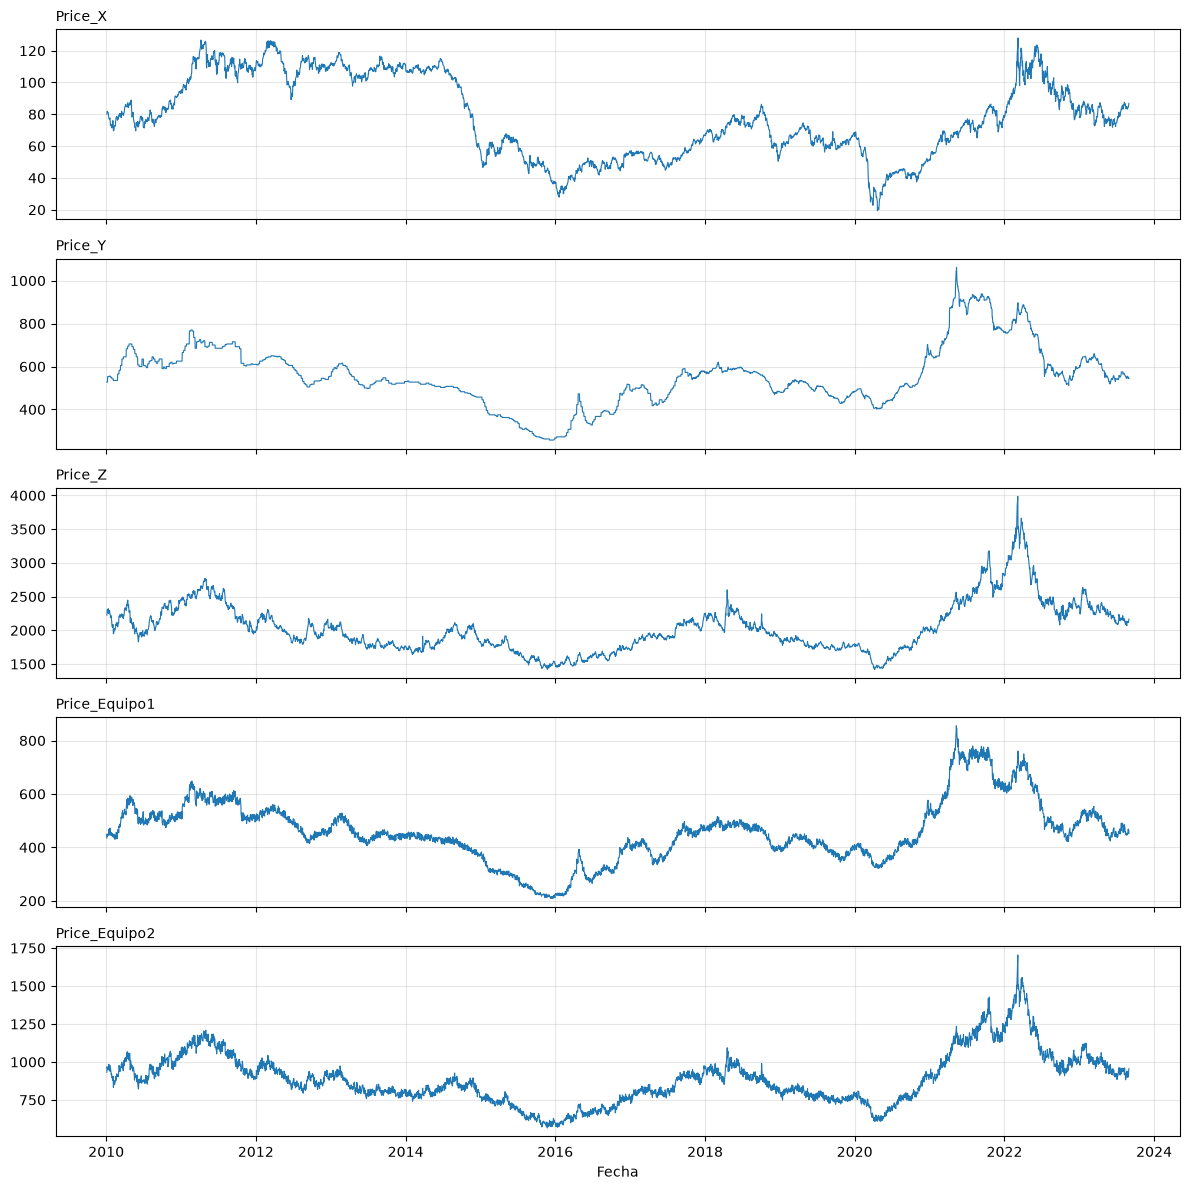

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
for ax, col in zip(axes, df.columns):
    ax.plot(df.index, df[col], linewidth=0.8)
    ax.set_title(col, loc="left", fontsize=10)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Fecha")
fig.tight_layout()
fig.savefig("../reports/figures/series_niveles.png", dpi=150, bbox_inches="tight")
plt.show()

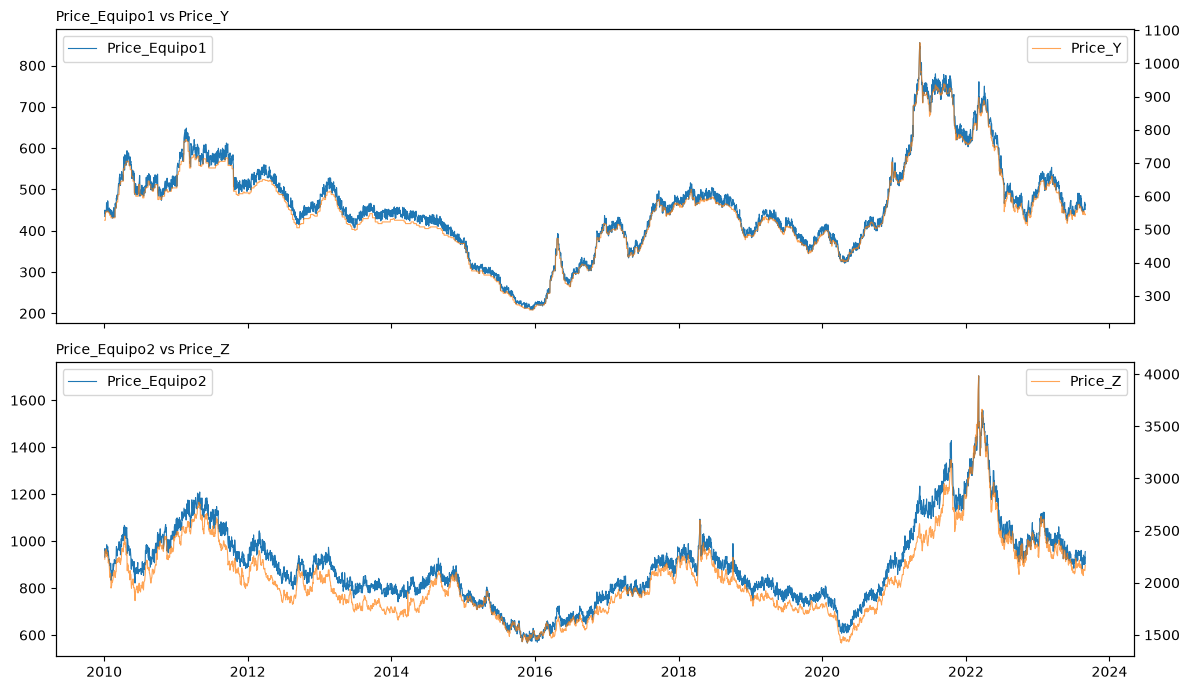

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
pares = [("Price_Equipo1", "Price_Y"), ("Price_Equipo2", "Price_Z")]
for ax, (eq, mp) in zip(axes, pares):
    ax.plot(df.index, df[eq], color="tab:blue", linewidth=0.8, label=eq)
    ax2 = ax.twinx()
    ax2.plot(df.index, df[mp], color="tab:orange", linewidth=0.8, alpha=0.7, label=mp)
    ax.set_title(f"{eq} vs {mp}", loc="left", fontsize=10)
    ax.legend(loc="upper left"); ax2.legend(loc="upper right")
fig.tight_layout()
fig.savefig("../reports/figures/equipos_vs_insumo.png", dpi=150, bbox_inches="tight")

#### Retornos

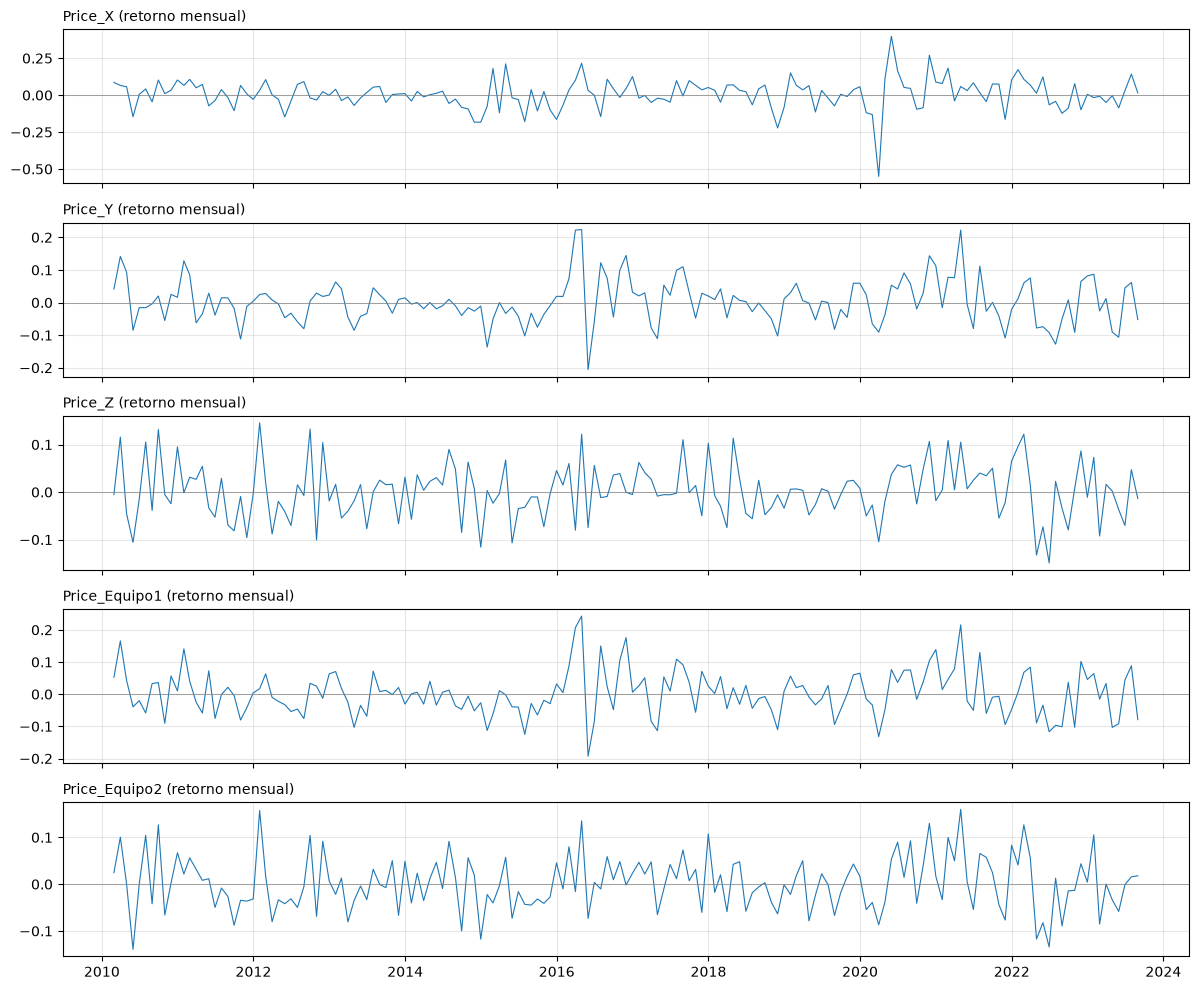

In [6]:
m = df.resample("ME").last()
r = m.pct_change().dropna()

fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
for ax, col in zip(axes, r.columns):
    ax.plot(r.index, r[col], linewidth=0.8)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_title(f"{col} (retorno mensual)", loc="left", fontsize=10)
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../reports/figures/retornos_mensuales.png", dpi=150, bbox_inches="tight")

### Correlaciones

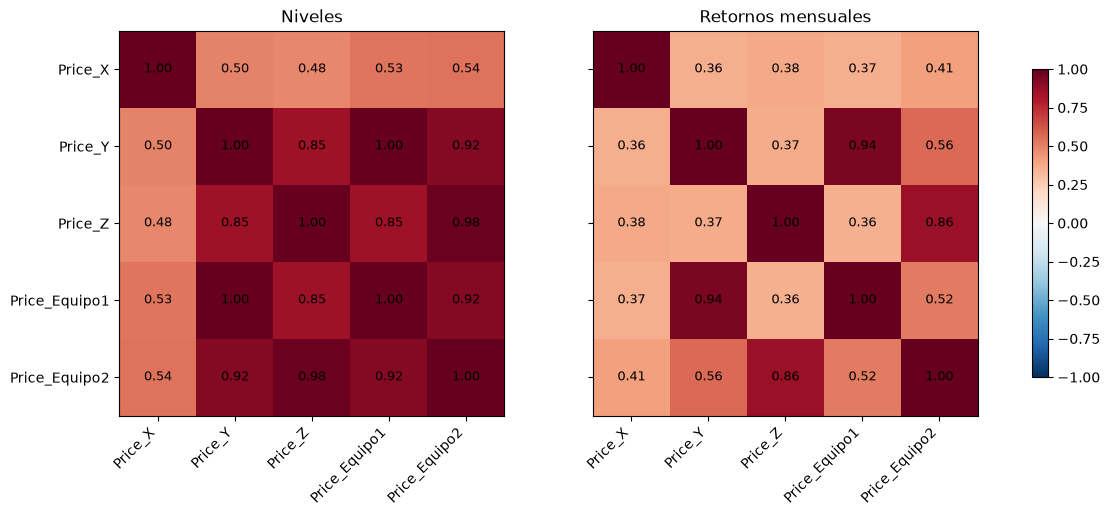

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (data, titulo) in zip(axes, [(m, "Niveles"), (r, "Retornos mensuales")]):
    c = data.corr()
    im = ax.imshow(c, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(5)); ax.set_xticklabels(c.columns, rotation=45, ha="right")
    ax.set_yticks(range(5)); ax.set_yticklabels(c.columns)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f"{c.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
    ax.set_title(titulo)
    axes[1].set_yticklabels([])
fig.colorbar(im, ax=axes, shrink=0.8)
fig.savefig("../reports/figures/correlaciones.png", dpi=150, bbox_inches="tight")


# Niveles me da la tendencia y eso infla 
# Retornos quitan la tendencia y me da la correlación de los movimientos

### Verificar estacionariedad, ADF
###### hipótesis nula es "la serie tiene raíz unitaria" (no estacionaria). Si p-value < 0.05 rechazás y la serie es estacionaria
###### Una serie con raíz unitaria no tiene una media fija a la que regresar cada valor arranca desde el anterior y los shocks se acumulan sin disiparse, por lo que puede irse a cualquier nivel.
###### Si se regresa dos series con raíz unitaria una contra otra, la regresión te va a dar R² alto y coeficientes significativos aunque no tengan ninguna relación.

In [8]:
from statsmodels.tsa.stattools import adfuller

filas = []
for col in m.columns:
    p_niv = adfuller(m[col].dropna())[1]
    p_ret = adfuller(r[col].dropna())[1]
    filas.append({"serie": col, "p_niveles": round(p_niv, 4), "p_retornos": round(p_ret, 4)})

adf_tbl = pd.DataFrame(filas)
adf_tbl.to_csv("../reports/adf.csv", index=False)
adf_tbl

,serie,p_niveles,p_retornos
0,Price_X,0.2955,0.0000
1,Price_Y,0.0261,0.0018
2,Price_Z,0.2173,0.0000
3,Price_Equipo1,0.2284,0.0001
4,Price_Equipo2,0.0195,0.0011


X, Z y Equipo 1 presentan raíz unitaria (mayores al 5%)
Y y Equipo 2 rechazan al 5%
Dado que en niveles todas las series muestran alta persistencia, se procede a verificar cointegración para los  candidatos


### Cointegración
Dos series no estacionarias tienen una combinación lineal que sí es estacionaria
Dos series que por separado deambulan sin rumbo fijo, juntas mantienen una relación estable en el tiempo: si una se aleja de la otra, tarde o temprano vuelven a alinearse.

In [9]:
from statsmodels.tsa.stattools import coint

pares = [(eq, mp) for eq in ["Price_Equipo1", "Price_Equipo2"]
                  for mp in ["Price_X", "Price_Y", "Price_Z"]]
filas = []
for eq, mp in pares:
    p = coint(m[eq], m[mp])[1]
    filas.append({"equipo": eq, "insumo": mp, "p_coint": round(p, 4)})

coint_tbl = pd.DataFrame(filas)
coint_tbl.to_csv("../reports/coint.csv", index=False)
coint_tbl

,equipo,insumo,p_coint
0,Price_Equipo1,Price_X,0.4868
1,Price_Equipo1,Price_Y,0.0128
2,Price_Equipo1,Price_Z,0.0474
3,Price_Equipo2,Price_X,0.3851
4,Price_Equipo2,Price_Y,0.3168
5,Price_Equipo2,Price_Z,0.0101


Cointegrados en aquellos inferiores a 5%. 
Al equipo_2 lo explica Z.
Al equipo_1 lo explica Y y estadsiticamente Z, pero tiene baja correlación en retornos, creo que es un falso positivo. Además Y está altamente correlacionado en niveles con Z, y ya Y pasó, meter a Z sería inflar la ecuación (haría un R2 alto sin necesidad), igual entra.
Cómo están cointegrados, el modelo es válido también en niveles.

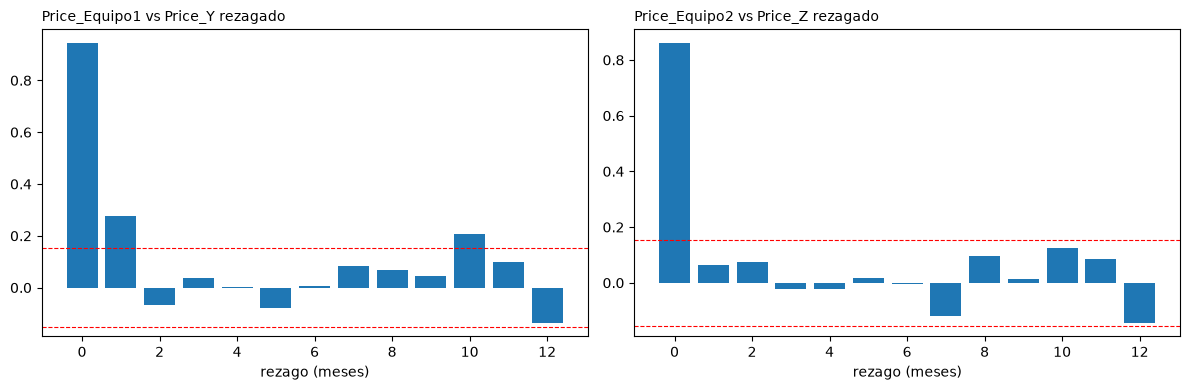

In [12]:
# Correlación cruzada de los retornos mensuales
from statsmodels.tsa.stattools import ccf
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pares = [("Price_Equipo1", "Price_Y"), ("Price_Equipo2", "Price_Z")]
for ax, (eq, mp) in zip(axes, pares):
    c = ccf(r[eq], r[mp], adjusted=False)[:13]
    ax.bar(range(13), c)
    ax.axhline(1.96 / len(r) ** 0.5, color="red", linestyle="--", linewidth=0.8)
    ax.axhline(-1.96 / len(r) ** 0.5, color="red", linestyle="--", linewidth=0.8)
    ax.set_title(f"{eq} vs {mp} rezagado", loc="left", fontsize=10)
    ax.set_xlabel("rezago (meses)")
fig.tight_layout()
fig.savefig("../reports/figures/ccf.png", dpi=150, bbox_inches="tight")

### Conclusiones del análisis exploratorio

- **Relación visual:** Equipo 1 replica la trayectoria de Y y Equipo 2 la de Z. X sigue una dinámica propia (caídas de 2014 y 2020 que no se transmiten a los equipos).
- **Correlaciones:** en retornos mensuales, Equipo 1 con Y = 0.94 y Equipo 2 con Z = 0.86. X no supera 0.41 con ningún equipo. La correlación Equipo 2 con Y (0.92 en niveles) cae a 0.56 en retornos, lo que indica tendencia compartida vía Z más que relación directa.
- **Estacionariedad (ADF):** X, Z y Equipo 1 presentan raíz unitaria en niveles. Y y Equipo 2 rechazan al 5% pero no al 1% (evidencia límite). Todos los retornos son estacionarios. Esto obliga a verificar cointegración antes de modelar precios contra precios.
- **Cointegración:** solo Equipo 1 con Y (p = 0.013) y Equipo 2 con Z (p = 0.010) están cointegrados. Equipo 1 con Z da p = 0.047, marginal y explicable por la correlación Y–Z. se descarta en la fase de modelado si no aporta poder explicativo adicional.
- **Decisión preliminar:** el insumo dominante de cada equipo es Y (Equipo 1) y Z (Equipo 2), y la cointegración habilita modelar en niveles. El análisis bivariado sugiere descartar X, pero esta conclusión se revisa en la fase de modelado: la regresión múltiple muestra que X participa en ambos equipos con peso significativo. La correlación y la cointegración identifican las relaciones dominantes, no la estructura completa.

### Luego de ver sus regresiones lineales

La regresión múltiple sobre las tres materias primas revela que los precios de los equipos son
combinaciones lineales exactas de los insumos, no relaciones estadísticas aproximadas:

| Equipo | Coeficientes estimados | Fórmula |
|---|---|---|
| Equipo 1 | X = 0.1983, Y = 0.8006, Z = -0.0001 (p = 0.88), const = 0.04 (p = 0.97) | **0.2·X + 0.8·Y** |
| Equipo 2 | X = 0.3353, Y = 0.3353, Z = 0.3322, const = 0.64 (p = 0.60) | **(X + Y + Z)/3** |

Los intervalos de confianza al 95% contienen los valores 0.20/0.80 y 1/3 respectivamente, y los
interceptos no son significativos, lo que confirma que no hay término independiente.

Al aplicar las fórmulas, los residuos tienen media prácticamente cero (-0.004 y -0.373) y un error
porcentual medio de 0.30% y 0.25%, sin estructura temporal visible. Se concluye que el residuo es
ruido aditivo, no información no capturada.

**Implicación metodológica:** no es necesario estimar un modelo predictivo de la relación
insumo-equipo, porque la relación es determinística. El problema de proyectar el costo de los
equipos se reduce a proyectar X, Y y Z, y aplicar las fórmulas. Toda la incertidumbre del pronóstico
proviene de la proyección de las materias primas.

**Nota sobre el proceso:** la correlación bivariada identificaba correctamente el insumo dominante
de cada equipo (Y para el 1, Z para el 2) pero no detectaba los aportes secundarios, porque la
volatilidad propia de X enmascara su contribución cuando se mide sin condicionar a las otras
variables. La regresión múltiple fue necesaria para recuperar la estructura completa.